<a href="https://colab.research.google.com/github/DanielaM26/SMS_SpamDetection/blob/main/SMS_Spam_Detection_Project_Daniela_Anamaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install gensim -U

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import sys
import traceback
import re
print(f"Python {sys.version}")

from matplotlib import pyplot as plt

"""
We need to make this determinitsic so we can keep a track of changes we do to the model
If we are using the same initialisation all the time, then changes
"""
import numpy as np
import pandas as pd

np.random.seed(317)

import random

random.seed(317)

try:
  import nltk
  nltk.download('stopwords')
  nltk.download('wordnet')
  from nltk.corpus import stopwords
  from nltk import WordNetLemmatizer
except:
  print("No nltk")

try:
    import torch

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    # DEVICE = 'cpu'
    print(f"PyTorch {torch.__version__}")
    print(f"DEVICE={DEVICE}")
    if torch.cuda.is_available():
        print(f"\tGPU: {torch.cuda.get_device_name(0)}")
        print(f"\t\tcapability: {torch.cuda.get_device_capability('cuda')[0]}")
        print(f"\tCUDA version: {torch.version.cuda}")
        print("\tcuDNN available: ", torch.backends.cudnn.is_available())

        if torch.backends.cudnn.is_available():
            print("\t\tcuDNN version: ", torch.backends.cudnn.version())

        # Print the number of GPUs available
        print(f"\tNumber of GPUs available: {torch.cuda.device_count()}")

    from torch import nn
    from torch.nn import functional as F
    from torch.optim import AdamW
    from torch.utils.data import Dataset, DataLoader

    torch.manual_seed(317)
except:
    print("No PyTorch")
    print(traceback.format_exc())

try:
    import tensorflow as tf

    print(f"TensorFlow {tf.__version__}")
    print(f"Build with CUDA: {tf.test.is_built_with_cuda()}")
    print(f"Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
except:
    print("No TensorFlow")

try:
  from transformers import BertTokenizer, BertForSequenceClassification
  from tqdm import tqdm

  #print(f"Tokenizer version {BertTokenizer.__version__}")
except:
  print("No Transformers")

try:
  import sklearn
  from sklearn.model_selection import train_test_split
  from sklearn.metrics import accuracy_score
  from sklearn.model_selection import train_test_split
  from sklearn.feature_extraction.text import TfidfVectorizer
  print(f"scikit-learn {sklearn.__version__}")
except:
  print("No scikit-learn")

from gensim.downloader import load as gensim_load

# DEVICE="cpu"
#Anamaria si Daniela

Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


PyTorch 2.9.0+cpu
DEVICE=cpu
TensorFlow 2.19.0
Build with CUDA: True
Num GPUs Available:  0


scikit-learn 1.6.1


# Classification in NLP

Computers cannot directly process text as humans do — they need numerical representations.

In Natural Language Processing (NLP), the goal of text vectorization is to transform tokens, words, sentences, or documents into numerical vectors that preserve meaningful information about their content.

For this laboratory we will consider two main types of text representation:
1. Sparse Representations - Daniela
2. Dense Representations - Anamaria

## Sparse representations

Sparse models like Bag-of-Words (BoW) and TF–IDF (Term Frequency–Inverse Document Frequency) use word counts or frequencies in order to represent text.
Each dimension corresponds to a unique term in the vocabulary, so the vectors are very large and mostly filled with zeros (sparse representation).

If the vocabulary is [I, cats, eat, cheeseburgers, love, the, without ...], then:

> “I love cheeseburgers” → [1, 0, 0, 1, 1, 0, 0 ...]

> “Cats eat cheeseburgers” → [0, 1, 1, 1, 0, 0, 0 ...]

Having this sparse representation, we have a a series of advantages:
* Simple and interpretable
* Works for small datasets
* Effective for linear models

But, there are considerable disadvantages:
* High dimensionality 🙃 - again, prediction models with many inputs
* No notion of meaning between words. We lose any information from word semantics
* No context for words. Word order does not influence the representations. "Cats eat rats" will have the same representation as "Rats eat cats".

## Dense representations

Dense models like Word2Vec, GloVe, or contextual models like BERT represent words as continuous-valued vectors in a low-dimensional space (tens to hundreds of dimensions). These vectors capture semantic relationships learned from large text corpora.

Instead of one-hot encodings, each word gets a unique position in space, such that similar words have similar embeddings.

cosine_similarity("king", "queen") ~ cosine_similarity("man", "woman")

For each token in my vocabulary, I have a vector of a given dimension.

  > “I” → [0.42, -0.11, 0.55, ...]
  
  > “Cats” → [0.22, -0.31, 0.10 ...]

Considering this representation (and comparing against the previous one), the advantages are clear:

* Semantic similarity is captured between words. The embeddings are meaningful with respect to the semantic.
* Compact and efficient (and performant)
* Useful for transfer learning (train once on a large corpus and then use it out of the box for different use-cases)

There are also disadvantages that we must take into account:
* Large corpus and the requirements for training
* Less interpretable. We do not know what these features represent, as they are learned by the model.




# [Section 1] Spam Classification

##Term Frequency-Inverse Document Frequency (TF-IDF)

TF–IDF (Term Frequency–Inverse Document Frequency) is one of the most common methods for transforming text into numerical feature vectors in Natural Language Processing (NLP). TF–IDF gives high importance to words that are frequent in one document, but rare across others. This helps the model focus on discriminative terms that distinguish one text from another.

TF-IDF combines two measures:
1. Term Frequency (TF) - how often a word appears in a single document. Reflects local importance.

> $TF(t, d) = \frac{\text{Number of times term } t \text{ appears in } d}{\text{Total number of terms in } d}$

2. Inverse Document Frequency (IDF) - how rare a term is across all documents. Reflects uniqueness.

> $IDF(t) = \log\left(\frac{N}{n_t}\right)$

Finally:

> $\text{TF–IDF}(t, d) = TF(t, d) \times IDF(t)$


## [Section 1.1] Load and visualize the data
*   Load the SMS dataset from drive
*   Load using pandas
*   Explore the data, see the texts, see the label distributions


In [6]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/proiect_ipit/sms+spam+collection/SMSSpamCollection"

# Dataset-ul original are format: <label>\t<text>
df = pd.read_csv(
    DATA_PATH,
    sep="\t",
    header=None,
    names=["label", "text"],
    encoding="utf-8",
    on_bad_lines="skip"
)

# mapare la eticheta numerica
df["spam"] = (df["label"].str.lower() == "spam").astype(int)

df.head()
#Anamaria si Daniela

,label,text,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [7]:
# Class distribution as table (count + percent)
counts = df["spam"].value_counts()
perc = df["spam"].value_counts(normalize=True) * 100
display(pd.DataFrame({"count": counts, "percent": perc.round(2)}))
# Anamaria


,count,percent
spam,,
0,4825,86.59
1,747,13.41


,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
1,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


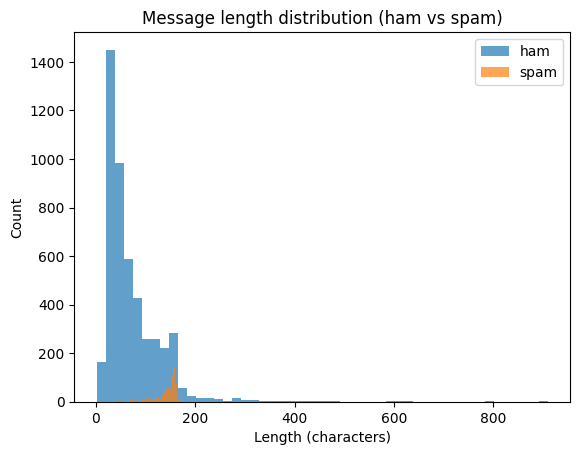

In [8]:
# Message length analysis
df["msg_len"] = df["text"].str.len()
display(df.groupby("spam")["msg_len"].describe())

# Optional: quick plot
import matplotlib.pyplot as plt
plt.figure()
plt.hist(df[df["spam"]==0]["msg_len"], bins=50, alpha=0.7, label="ham")
plt.hist(df[df["spam"]==1]["msg_len"], bins=50, alpha=0.7, label="spam")
plt.legend()
plt.title("Message length distribution (ham vs spam)")
plt.xlabel("Length (characters)")
plt.ylabel("Count")
plt.show()
#Daniela

## [Section 1.2] Text filtering
*   Remove unneeded characters - punctuation marks, special characters. Regex: [^a-zA-Z0-9]
*   Remove stopwords - the, a, for, in etc.
*   Lemmatize - convert words to their base form (remove prefixes, sufixes). Use lemmatizer.lemmatize(word)


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # First, let's remove unneeded characters
    text = re.sub('[^A-Za-z0-9]+', ' ', text.lower())

    # Split the words by space character and remove empty words
    words = [lemmatizer.lemmatize(word) for word in text.split(' ') if word.strip()]

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return words

In [10]:
words = clean_text(df["text"][0])
print(words)
#Anamaria

['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']


## [Section 1.3] Create the embedding functions.

Use [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)




In [11]:
#Daniela
def build_tfidf_encoder(texts):
    vectorizer = TfidfVectorizer(
      lowercase=True,
      strip_accents="unicode",
      analyzer="word",
      token_pattern=r"(?u)\b\w+\b",   # keep even 1-char tokens for completeness
      ngram_range=(1, 2),             # unigrams+bigrams
      min_df=1,                       # no pruning
      max_df=1.0,
      sublinear_tf=True,
      use_idf=True,
      smooth_idf=True,
      norm="l2",
      dtype=np.float32
    )
    X = vectorizer.fit_transform(texts).toarray().astype(np.float32)
    return vectorizer, X
#Anamaria
def vectorize(msg, w2v_model):
    words = clean_text(msg)
    words = [w for w in words if w in w2v_model.key_to_index]
    if not words:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model[words], axis=0)

def build_word2vec_encoder(texts):
     w2v_model = gensim_load("word2vec-google-news-300")  # 300D pretrained word2vec model
     # w2v_model = gensim_load("glove-wiki-gigaword-100")  # 100D pretrained GloVe model
     X = np.array([vectorize(t, w2v_model) for t in texts], dtype=np.float32)
     return w2v_model, X

In [12]:
# Test TF-IDF encoder (SMS) - Daniela
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf = vectorizer.fit_transform(df["text"])

print("TF-IDF shape:", X_tfidf.shape)          # (nr_mesaje, nr_features)
print("Non-zeros in first row:", X_tfidf[0].nnz)
print("Sample message:", df["text"].iloc[0])


TF-IDF shape: (5572, 14993)
Non-zeros in first row: 17
Sample message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [13]:
# Test word2vec encoder - Anamaria

w2v_model, X = build_word2vec_encoder(df['text'])
print(X[0])

[==================================================] 100.0% 1662.8/1662.8MB downloaded
[-0.01980591  0.05167062  0.02709961  0.21868025 -0.0310342   0.03897967
  0.08196586 -0.09603446  0.01432146  0.07736329 -0.06193366 -0.1637486
 -0.02575248 -0.0471889  -0.10367257  0.14072964  0.15539551  0.09352984
  0.03390067 -0.02132089 -0.0716391  -0.01377705  0.09657506  0.03925433
 -0.01184082  0.0204869  -0.12768555  0.02552141  0.0472363  -0.04317801
 -0.05688912  0.02345221 -0.05597796 -0.01293073 -0.01777867 -0.04088129
 -0.02099078 -0.02489035  0.02235821  0.03364781  0.03664725 -0.09109061
  0.13033621  0.05961827  0.02466256 -0.08101545 -0.09543718 -0.05844443
  0.01415144  0.10117885 -0.0839059   0.15156338 -0.02831377  0.01769148
 -0.05941882  0.08585031 -0.09414673 -0.1260376   0.04568917 -0.09597342
 -0.09876796  0.047869   -0.09463065 -0.06553432  0.01525879 -0.10970198
 -0.07511684  0.04650007 -0.01913779  0.10336304  0.07246617  0.05862863
  0.10284424  0.09385463 -0.0927372  -

## [Section 1.4] Create the Linear classifier on top


In [14]:
#Anamaria & Daniela
class LinearTextClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, 100)
        self.linear2 = nn.Linear(100, 10)
        self.linear3 = nn.Linear(10, 2)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = self.linear3(x)
        return x

## [Section 1.5] Construct the training loop and train your model


In [15]:
#Daniela
def train_classifier(X, y, epochs=50, lr=0.01):
    # Split into train and test, 70/30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Define model (LinearTextClassifier), criterion (CrossEntropyLoss) and optimizer (AdamW)
    model = LinearTextClassifier(input_dim=len(X_train[0]))
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Create tensors for your data
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.long)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                # Compute and print accuracy and loss on test dataset
                logits = model(X_test_t)
                acc = (logits.argmax(1) == y_test_t).float().mean().item()
                print(f"Epoch {epoch + 1}: Loss - {loss.item()}, Accuracy - {acc}")

    return model



In [16]:
method_to_use = 'tf-idf'
#method_to_use = 'word2vec'

if method_to_use == 'tf-idf':
    encoder, X = build_tfidf_encoder(df['text'])
else:
    encoder, X = build_word2vec_encoder(df['text'])

model = train_classifier(X, df['spam'].to_numpy())
#Anamaria si Daniela

Epoch 10: Loss - 0.13475732505321503, Accuracy - 0.9742823243141174
Epoch 20: Loss - 0.0004225272568874061, Accuracy - 0.9832535982131958
Epoch 30: Loss - 2.746014069998637e-05, Accuracy - 0.9832535982131958
Epoch 40: Loss - 1.4161320905259345e-05, Accuracy - 0.9820573925971985
Epoch 50: Loss - 1.059117403201526e-05, Accuracy - 0.9820573925971985


## [Section 1.6] Inference and Testing

Create the predict function that predicts if an SMS is spam or ham by using the trained model.

In [17]:
# Inference - Anamaria
def predict(msg_list, fitted_encoder, method_to_use, model):
    model.eval()
    if method_to_use == 'tf-idf':
        # Use the already fitted TF-IDF vectorizer to transform the new messages
        # 'fitted_encoder' is expected to be the TfidfVectorizer object
        X = fitted_encoder.transform(msg_list).toarray().astype(np.float32)
    elif method_to_use == 'word2vec':
        # Use the already loaded Word2Vec/GloVe model to vectorize messages
        # 'fitted_encoder' is expected to be the gensim word2vec model
        X = np.array([vectorize(t, fitted_encoder) for t in msg_list], dtype=np.float32)
    else:
        raise ValueError(f"Unknown method_to_use: {method_to_use}")

    vec_t = torch.tensor(X)
    # Move tensor to the same device as the model
    device = next(model.parameters()).device # Get the device where the model is
    vec_t = vec_t.to(device)

    with torch.no_grad(): # No need to track gradients for inference
        pred = torch.argmax(model(vec_t), dim=1)
    return pred

# Call predict function on some examples.
msg = [  "WINNER!! You have won a £900 prize reward! Call 09061701461 now to claim your prize.",
    "Hey, I will arrive in about 15 minutes. Can you wait for me near the entrance?",
    "URGENT! You have been selected for a FREE gift. Reply YES now to claim. Limited time offer!",
    "Are we still meeting at 6 pm today? Let me know when you are on your way.",
    "FREE entry in 2 a weekly comp to win FA Cup final tickets. Text WIN to 80086 now!",
    "Don't forget to bring the documents tomorrow morning. Thanks!",
    "IMPORTANT! Claim your cash bonus today. Visit www.claim-bonus-now.com to get it.",
    "Ok, sounds good. See you later :)",
]
#encoder = None
#pred = predict(msg, encoder, "word2vec", model)
#print(pred)

pred = predict(msg, encoder, method_to_use, model)
print(pred.tolist())

[1, 0, 1, 0, 1, 0, 1, 0]


## [Section 2] Batch training.



In [18]:
# Daniela
# The training procedure is adapted to use mini-batches.
# A Dataset class and DataLoader objects are used to iterate over the data in batches,
# and the training loop is updated to process one batch at a time.

from torch.utils.data import Dataset

# Implementation of Dataset
class EmailDataset(Dataset):
  def __init__(self, X, y, transform = None):
    self.X = X
    self.y = y
    self.transform = transform
    self.len = len(X)

  def __getitem__(self, idx):
    X, y = self.X[idx], self.y[idx]
    if self.transform:
      X = self.transform(X)
    return X, y

  def __len__(self):
      return self.len

In [19]:
from torch.utils.data import DataLoader

def train_one_epoch(epoch_index, model, train_loader, criterion, optimizer):
  running_loss = 0.
  last_loss = 0.

  batches = len(train_loader)

  # We enumerate through training data
  for i, batch in enumerate(train_loader):
    # Extract features and labels
    inputs, labels = batch

    # Zero gradient
    optimizer.zero_grad()

    # Make predictions
    outputs = model(inputs)

    # Compute loss and gradients
    loss = criterion(outputs, labels)
    loss.backward()

    # Adjust learning weights
    optimizer.step()

    # Gather data and create a report
    running_loss += loss.item()
    if i % 50 == 49 or i == batches - 1:
      last_loss = running_loss / 50 if i % 10 == 49 else running_loss / (batches - int(i / 50) * 50)
      print(f"Epoch {epoch_index} [{i + 1}/{batches}] - Loss: {last_loss}")
      running_loss = 0.

  return last_loss

# Implement a batch training function
def batch_train_classifier(X, y, epochs=10, lr=0.01):
    # Split into train and test, 70/30
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Define model (LinearTextClassifier), criterion (CrossEntropyLoss) and optimizer (AdamW)
    model = LinearTextClassifier(input_dim=len(X_train[0]))
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Create dataset objects for train/test
    train_ds = EmailDataset(X_train, y_train)
    test_ds = EmailDataset(X_test, y_test)

    # Create dataloader objects for train/test
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    # Report split sizes
    print(f"Training set has {len(train_ds)} instances.")
    print(f"Validation set has {len(test_ds)} instances.")

    for epoch in range(epochs):
        # Activate gradient tracking
        model.train()
        avg_loss = train_one_epoch(epoch + 1, model, train_loader, criterion, optimizer)

        # Disable gradient computation
        model.eval()
        running_vloss = 0.

        # Measure accuracy
        total_correct = 0
        total_instances = 0

        with torch.no_grad():
          for i, vbatch in enumerate(test_loader):
            vinputs, vlabels = vbatch
            voutputs = model(vinputs)

            # Compute the loss
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss.item()

            # Compute the accuracy
            vpreds = voutputs.argmax(dim=1)
            total_correct += (vpreds == vlabels).sum().item()
            total_instances += vlabels.size(0)

        avg_vloss = running_vloss / (i + 1)
        accuracy = total_correct / total_instances

        print(f"Epoch {epoch + 1} - Train Loss: {avg_loss}, Valid Loss: {avg_vloss}, Accuracy: {accuracy}\n")

    return model


In [20]:
model = batch_train_classifier(X, df['spam'].to_numpy())

Training set has 3900 instances.
Validation set has 1672 instances.
Epoch 1 [50/122] - Loss: 0.0914617057920235
Epoch 1 [100/122] - Loss: 0.04974017682737516
Epoch 1 [122/122] - Loss: 0.07002808871171014
Epoch 1 - Train Loss: 0.07002808871171014, Valid Loss: 0.04678429212456323, Accuracy: 0.9874401913875598

Epoch 2 [50/122] - Loss: 0.0011646576762747126
Epoch 2 [100/122] - Loss: 0.0007368551613985295
Epoch 2 [122/122] - Loss: 0.0038347157513437032
Epoch 2 - Train Loss: 0.0038347157513437032, Valid Loss: 0.04631758332230537, Accuracy: 0.9910287081339713

Epoch 3 [50/122] - Loss: 0.000163415834948432
Epoch 3 [100/122] - Loss: 0.00016954877588028062
Epoch 3 [122/122] - Loss: 8.685606818206989e-05
Epoch 3 - Train Loss: 8.685606818206989e-05, Valid Loss: 0.053058473520718935, Accuracy: 0.9874401913875598

Epoch 4 [50/122] - Loss: 2.261648418067632e-05
Epoch 4 [100/122] - Loss: 4.747121523804607e-05
Epoch 4 [122/122] - Loss: 0.00015915069949104773
Epoch 4 - Train Loss: 0.0001591506994910477

In [23]:
# Call predict function on some examples (SMS)
msg = [
    "WINNER!! You have won a £900 prize reward! Call 09061701461 now to claim your prize.",
    "Hey, I will arrive in about 15 minutes. Can you wait for me near the entrance?",
    "URGENT! You have been selected for a FREE gift. Reply YES now to claim. Limited time offer!",
    "Are we still meeting at 6 pm today? Let me know when you are on your way.",
    "FREE entry in 2 a weekly comp to win FA Cup final tickets. Text WIN to 80086 now!",
    "Don't forget to bring the documents tomorrow morning. Thanks!",
    "IMPORTANT! Claim your cash bonus today. Visit www.claim-bonus-now.com to get it.",
    "Ok, sounds good. See you later :)",
]

# Ensure encoder and method_to_use are correctly set for TF-IDF prediction
# This re-initializes them based on the original training setup in cell 'fsNovtodlXlZ'
# in case they were altered by other cells.
#global encoder, method_to_use
#method_to_use = 'tf-idf'
# We need to ensure df is available and build_tfidf_encoder is defined
# Re-create the TF-IDF encoder. In a real application, you would load a saved encoder.
#if 'df' in globals() and 'build_tfidf_encoder' in globals():
 #   encoder, _ = build_tfidf_encoder(df['text'])
#else:
 #   print("Warning: 'df' or 'build_tfidf_encoder' not found. Please ensure previous cells are run.")
    # Fallback or error handling if df/build_tfidf_encoder are not available

pred = predict(msg, encoder, method_to_use, model)
print(list(zip(msg, pred.tolist())))

[('WINNER!! You have won a £900 prize reward! Call 09061701461 now to claim your prize.', 1), ('Hey, I will arrive in about 15 minutes. Can you wait for me near the entrance?', 0), ('URGENT! You have been selected for a FREE gift. Reply YES now to claim. Limited time offer!', 1), ('Are we still meeting at 6 pm today? Let me know when you are on your way.', 0), ('FREE entry in 2 a weekly comp to win FA Cup final tickets. Text WIN to 80086 now!', 1), ("Don't forget to bring the documents tomorrow morning. Thanks!", 0), ('IMPORTANT! Claim your cash bonus today. Visit www.claim-bonus-now.com to get it.', 1), ('Ok, sounds good. See you later :)', 0)]


## Results tables

The tables below summarize performance on the test split.

In [22]:
#Anamaria si Daniela
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Assuming X (vectorized features) and df['spam'] (labels) are available globally
# Re-perform the train-test split to get X_test and y_test in the global scope
# Use the same split ratio as in train_classifier and batch_train_classifier
_, X_test_features, _, y_test = train_test_split(X, df['spam'].to_numpy(), test_size=0.3, random_state=None) # random_state=None for a new split or specify if needed

# Generate predictions for the test set using the trained model and encoder
# Note: predict function expects raw text, but X_test_features is already processed.
# We need to re-vectorize X_test_raw_text if we want to use the predict function directly.
# Alternatively, we can use the model directly on X_test_features.

# Let's use the model directly on X_test_features as it's already in the correct format for the model
model.eval() # Set model to evaluation mode
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_features, dtype=torch.float32)
    # Move input to the same device as the model
    model_device = next(model.parameters()).device
    X_test_tensor = X_test_tensor.to(model_device)

    logits = model(X_test_tensor)
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

# 1) Classification report table
report = classification_report(y_test, y_pred, output_dict=True, digits=4)
report_df = pd.DataFrame(report).T
display(report_df)

# 2) Confusion matrix as a table
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["true_ham(0)", "true_spam(1)"], columns=["pred_ham(0)", "pred_spam(1)"])
display(cm_df)


,precision,recall,f1-score,support
0,0.996530,1.000000,0.998262,1436.00000
1,1.000000,0.978814,0.989293,236.00000
accuracy,0.997010,0.997010,0.997010,0.99701
macro avg,0.998265,0.989407,0.993778,1672.00000
weighted avg,0.997020,0.997010,0.996996,1672.00000


,pred_ham(0),pred_spam(1)
true_ham(0),1436,0
true_spam(1),5,231
